# Student Segmentation Workflow

## Overview

This notebook builds an unsupervised learning pipeline to group students into segments based on their background, study habits, and support-related features.

The goal is to discover patterns in the student data without using the grade columns directly, then inspect how the clusters differ and how a new student would be assigned to one of those clusters.

In [1]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd

## Data Loading

The dataset is loaded from the shared student information file used across the project.

At this stage, the notebook only confirms that the data is available and ready for segmentation. No transformation is applied yet.

In [2]:
df = pd.read_csv('../Data/student_information.csv')

## Feature Selection for Segmentation

The grade columns `G1`, `G2`, and `G3` are removed because segmentation should be based on student profile features rather than academic outcomes.

The remaining columns are split into categorical and numerical groups so they can be transformed appropriately in the preprocessing pipeline.

In [3]:
X_seg = df.drop(columns=["G1", "G2", "G3"])
    
categorical_cols = X_seg.select_dtypes(
    include=["object"]
).columns

numerical_cols = X_seg.select_dtypes(
    exclude=["object"]
).columns

## Preprocessing Pipeline

The preprocessing step standardizes numerical variables and one-hot encodes categorical variables before clustering.

This is important because KMeans relies on distance calculations, so all features need to be converted into a comparable numeric representation.

In [4]:
preprocessor_seg = ColumnTransformer([
    (
        "num",
        StandardScaler(),
        numerical_cols
    ),
    (
        "cat",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_cols
    )
])

## Segmentation Pipeline

The full pipeline combines preprocessing, dimensionality reduction with PCA, and KMeans clustering.

PCA reduces the transformed feature space to two dimensions so the clusters can be visualized more clearly, while KMeans assigns each student to one of three groups.

In [5]:
segmentation_pipeline = Pipeline([
    ("preprocessor", preprocessor_seg),
    ("pca", PCA(n_components=2)),
    ("model", KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10
    ))
])

## Fitting the Clustering Model

The pipeline is fitted on the full segmentation feature set so it can learn the structure of the student population.

Because this is unsupervised learning, there is no target variable here. The model discovers groups based only on the feature patterns it sees in the data.

In [6]:
segmentation_pipeline.fit(X_seg)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

## Cluster Assignment

After fitting, the processed data is projected into PCA space and each student is assigned to a cluster.

This step prepares both the plotted visualization and the later cluster-level analysis.

In [7]:
X_processed = segmentation_pipeline.named_steps[
    "preprocessor"
].transform(X_seg)

X_pca = segmentation_pipeline.named_steps[
    "pca"
].transform(X_processed)

clusters = segmentation_pipeline.named_steps[
    "model"
].predict(X_pca)

## Cluster Visualization

The scatter plot below shows the students in two-dimensional PCA space, colored by the cluster assigned by KMeans.

If the clusters separate cleanly, that suggests the feature space contains meaningful group structure. If the clusters overlap, the segments are still useful, but the boundaries are less distinct.

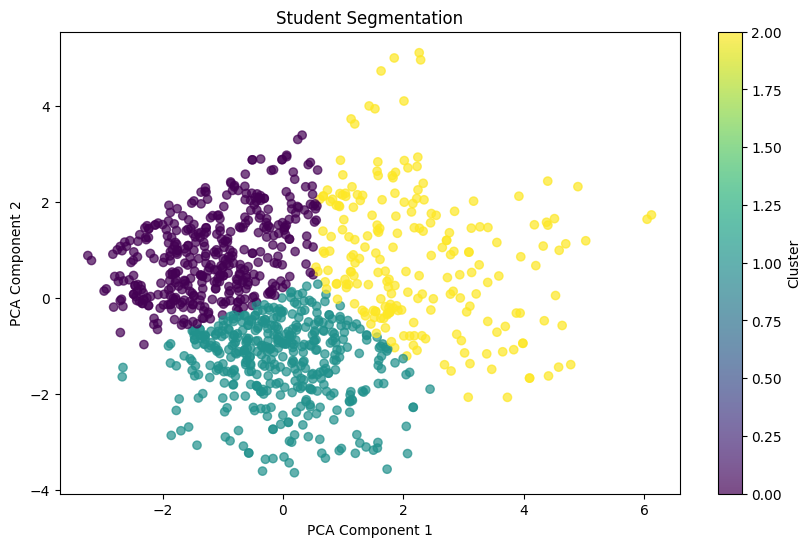

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    alpha=0.7
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title("Student Segmentation")

plt.colorbar(label="Cluster")

plt.show()

## Example Student Assignment

This section creates a sample student profile and runs it through the same preprocessing and clustering pipeline.

The red point on the plot shows where that student falls in the PCA space and which cluster the model assigns to them.

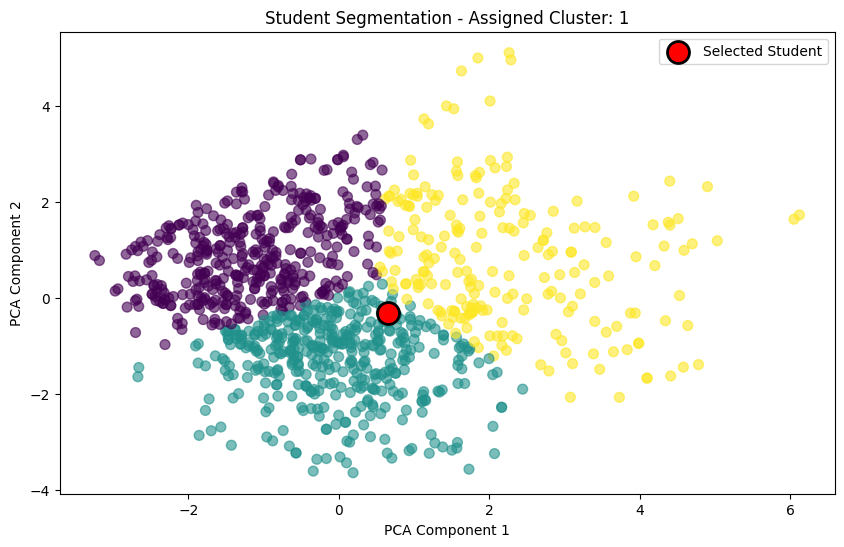

In [9]:
student_data = {
  "school": "GP",
  "sex": "F",
  "age": 17,
  "address": "U",
  "famsize": "GT3",
  "Pstatus": "T",
  "Medu": 4,
  "Fedu": 4,
  "Mjob": "teacher",
  "Fjob": "services",
  "reason": "course",
  "guardian": "mother",
  "traveltime": 4,
  "studytime": 0,
  "failures": 3,
  "schoolsup": "no",
  "famsup": "yes",
  "paid": "no",
  "activities": "yes",
  "nursery": "yes",
  "higher": "yes",
  "internet": "yes",
  "romantic": "no",
  "famrel": 4,
  "freetime": 0,
  "goout": 0,
  "Dalc": 1,
  "Walc": 2,
  "health": 0,
  "absences": 50
}

student_df = pd.DataFrame([student_data])

student_processed = segmentation_pipeline.named_steps["preprocessor"].transform(
    student_df
)

student_pca = segmentation_pipeline.named_steps["pca"].transform(
    student_processed
)

student_cluster = segmentation_pipeline.named_steps["model"].predict(
    student_pca
)[0]

plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    alpha=0.6,
    s=50
)

plt.scatter(
    student_pca[0, 0],
    student_pca[0, 1],
    color="red",
    s=250,
    edgecolors="black",
    linewidths=2,
    label="Selected Student"
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"Student Segmentation - Assigned Cluster: {student_cluster}")
plt.legend()
plt.show()

## Attach Cluster Labels

The assigned cluster IDs are written back to the original dataframe as a new `segment` column.

This makes it possible to summarize each segment using the original student records rather than only the transformed PCA space.

In [10]:
df["segment"] = clusters

In [11]:
clusters = segmentation_pipeline.named_steps[
    "model"
].predict(X_pca)

## Segment Profile Summary

The grouped averages below describe the typical student profile inside each cluster.

This is the most useful post-clustering step because it turns abstract cluster IDs into interpretable segment characteristics that can be used for messaging or intervention design.

In [12]:
cluster_analysis = df.groupby("segment").mean(
    numeric_only=True
)

cluster_analysis

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
segment,,,,,,,,,,,,,,,,
0,16.411765,3.556373,3.276961,1.225490,2.142157,0.039216,4.029412,3.164216,3.066176,1.252451,2.029412,3.539216,4.218137,12.245098,12.382353,12.610294
1,16.783333,1.845238,1.652381,1.650000,2.026190,0.288095,3.864286,2.945238,2.742857,1.152381,1.714286,3.357143,3.654762,10.961905,10.919048,10.935714
2,17.208333,2.277778,2.138889,1.837963,1.537037,0.643519,3.898148,3.768519,4.129630,2.615741,3.875000,3.912037,6.361111,9.754630,9.736111,9.736111


## Saving Cluster Artifacts

The cluster name mapping and fitted segmentation pipeline are saved with joblib so they can be reused later.

Saving both the model and the label mapping makes it easier to interpret cluster IDs consistently in the backend or in future analysis notebooks.

In [13]:
import os
import joblib

In [14]:
cluster_names = {
    0: "High Achievers",
    1: "Average / Stable",
    2: "At-Risk / Socially Active"
}

joblib.dump(
    cluster_names,
    "models/cluster_names.pkl"
)

['models/cluster_names.pkl']

In [15]:
os.makedirs("models", exist_ok=True)

joblib.dump(
    segmentation_pipeline,
    "models/segmentation_model.pkl"
)

['models/segmentation_model.pkl']

## Summary

This notebook segments students into three groups using an unsupervised clustering pipeline.

The main outputs are the fitted clustering model, the cluster-to-name mapping, the two-dimensional visualization, and the segment-level summary statistics. These artifacts can be reused for interpretation or downstream applications.